#**Array Element Ranking**

In [4]:
# Cloning the repository in the notebook
import os

REPO_OWNER = "Epoch-2026-2027"
REPO_NAME = "Learning_Phase"
BRANCH_NAME = "Utkarsh"

REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"

if not os.path.exists(REPO_NAME):
    !git clone -b {BRANCH_NAME} {REPO_URL}
else:
    print(f"Directory '{REPO_NAME}' already exists.")

os.chdir(REPO_NAME)
print(f"Current working directory changed to: {os.getcwd()}")

Cloning into 'Learning_Phase'...
remote: Enumerating objects: 1225, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 1225 (delta 10), reused 0 (delta 0), pack-reused 1161 (from 2)
Receiving objects: 100% (1225/1225), 224.03 MiB | 29.97 MiB/s, done.
Resolving deltas: 100% (254/254), done.
Current working directory changed to: /content/Learning_Phase


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Importing the necessary libraries

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

##**Data Pre-processing**

In [6]:
# Loading the data and separating it into the sequences (X)
# and the rankings (y)

ranking_data = pd.read_csv('/content/Learning_Phase/Task-1/Subtask-1/ranking_dataset.csv')
X = ranking_data.iloc[:, 0:10].copy()
y = ranking_data.iloc[:, 10:20].copy()

In [ ]:
# Sequence Normalization

# Z-score Normalization
X_norm_zscore = X.sub(X.mean(axis=1), axis=0).div(X.std(axis=1), axis=0)
X_norm = X_norm_zscore.copy()

In [ ]:
# Splitting the data into train, validation and test sets
# with a ratio of 70%-15%-15%

X_non_test, X_test, y_non_test, y_test = train_test_split(
    X_norm, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_non_test, y_non_test, test_size=0.177, random_state=42
)

In [ ]:
# Wrapping the split data into a PyTorch Dataset

class RankingDataset(Dataset):
    def __init__(self, X, y):
        # LLM used here for help with reshaping the tensor (unsqueeze)
        self.X = torch.tensor(X.values).float().unsqueeze(2)
        self.y = torch.tensor(y.values).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Creating the DataLoader instances for the training, validation and
# testing sets
train_loader = DataLoader(RankingDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(RankingDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(RankingDataset(X_test, y_test), batch_size=32, shuffle=False)

##**Baseline Model: (LSTM)**

In [ ]:
# Baseline LSTM Architecture

class LSTM(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
    super().__init__()

    # Initializing the LSTM parameters
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.output_dim = output_dim

    # Using a bidirectional LSTM
    self.lstm = nn.LSTM(
        input_size=self.input_dim,
        hidden_size=self.hidden_dim,
        num_layers=1,
        batch_first=True,
        bidirectional=True
    )

    # Defining the Fully-Connected Layers
    self.fully_connected = nn.Sequential(
        nn.Linear(2*self.hidden_dim, 32),
        nn.Dropout(0.3),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, self.output_dim)
    )

  # Defining the forward pass
  def forward(self, x):
      output, (hidden_state, cell_state) = self.lstm(x)
      # Passing the output state to the Fully-Connected Layers
      # for the predictions
      return self.fully_connected(output)

In [ ]:
# The training and validation loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_validate_LSTM(model, train_loader, validation_loader, epochs, lr):
  model.to(device)

  # Using the Adam Optimizer
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Using the Categorical Cross Entropy Loss
  CCELoss = nn.CrossEntropyLoss()

  training_losses = []
  validation_losses = []
  validation_accuracies_pct_token = []
  validation_accuracies_pct_sequence = []

  for epoch in range(epochs):
    # Training:
    model.train()
    total_training_loss = 0

    for sequence, ranks in train_loader:
      sequence = sequence.to(device)
      ranks = ranks.to(device)

      optimizer.zero_grad()

      # Forward pass
      predicted_ranks = model.forward(sequence)

      # Calculating the loss
      # LLM used here for help with the reshaping (.view calls)
      loss = CCELoss(predicted_ranks.view(-1, model.output_dim), ranks.view(-1))
      total_training_loss += loss.item()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

    # Printing the total training loss for that epoch:
    training_losses.append(total_training_loss)
    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch + 1}:")
      print(f"Training Loss = {total_training_loss:.4f}")

    # Validation:
    model.eval()
    total_validation_loss = 0
    correct_predictions_token = 0
    correct_predictions_sequence = 0

    with torch.no_grad():
      for sequence, ranks in validation_loader:
        sequence = sequence.to(device)
        ranks = ranks.to(device)

        # Forward pass
        predicted_ranks = model.forward(sequence)

        # Calculating the loss
        loss = CCELoss(predicted_ranks.view(-1, model.output_dim), ranks.view(-1))
        total_validation_loss += loss.item()

        # LLM used here for the syntax for dircectly calculating the token-wise
        # and sequence-wise correct predictions
        # Calculating the token-level accuracy
        predictions = torch.argmax(predicted_ranks, dim=2)
        correct_predictions_token += predictions.eq(ranks.view_as(predictions)).sum().item()
        # Calculating the sequence-level accuracy
        correct_predictions_sequence += torch.all(predictions.eq(ranks), dim=1).sum().item()

    validation_accuracy_token = (correct_predictions_token/(len(validation_loader.dataset)*model.output_dim))*100
    validation_accuracy_sequence = (correct_predictions_sequence/len(validation_loader.dataset))*100
    validation_losses.append(total_validation_loss)
    validation_accuracies_pct_token.append(validation_accuracy_token)
    validation_accuracies_pct_sequence.append(validation_accuracy_sequence)
    # Printing the total validation loss and validation accuracy for that epoch:
    if (epoch + 1) % 10 == 0:
      print(f"Validation Loss = {total_validation_loss:.4f}")
      print(f"Validation Accuracy (Token-level) = {validation_accuracy_token:.4f}%")
      print(f"Validation Accuracy (Sequence-level) = {validation_accuracy_sequence:.4f}%")
      print()

  # Plotting the training and validation loss plots along with the validation accuracy plot
  plt.figure(figsize=(6, 16))

  plt.subplot(4, 1, 1)
  plt.plot([(i+1) for i in range(epochs)], training_losses, color='red')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Training Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 2)
  plt.plot([(i+1) for i in range(epochs)], validation_losses, color='blue')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Validation Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 3)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct_token, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Token-level Accuracy Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 4)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct_sequence, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Sequence-level Accuracy Plot")
  plt.xlabel("Epoch")
  plt.grid(True, alpha=0.3)

  plt.suptitle(f"Training, Validation and Accuracy Plots\nEpochs = {epochs}, Learning Rate = {lr}")
  plt.show()

In [ ]:
# The testing loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_LSTM(model, test_loader):
  model.to(device)

  # Testing:
  model.eval()
  correct_predictions_token = 0
  correct_predictions_sequence = 0

  with torch.no_grad():
    for sequence, ranks in test_loader:
      sequence = sequence.to(device)
      ranks = ranks.to(device)

      # Forward pass
      predicted_ranks = model.forward(sequence)

      # Calculating the token-level accuracy
      predictions = torch.argmax(predicted_ranks, dim=2)
      correct_predictions_token += predictions.eq(ranks.view_as(predictions)).sum().item()
      # Calculating the seuqence-level accuracy
      correct_predictions_sequence += torch.all(predictions.eq(ranks), dim=1).sum().item()

    test_accuracy_token = (correct_predictions_token/(len(test_loader.dataset)*model.output_dim))*100
    test_accuracy_sequence = (correct_predictions_sequence/len(test_loader.dataset))*100
    # Printing the test accuracies (token-level and sequence-level)
    print(f"Test Accuracy (Token-level) = {test_accuracy_token:.4f}%")
    print(f"Test Accuracy (Sequence-level) = {test_accuracy_sequence:.4f}%")

In [ ]:
# Initializing the LSTM Model
EPOCHS = 100
LEARNING_RATE = 0.001
HIDDEN_DIM = 64
model_lstm = LSTM(1, HIDDEN_DIM, 10)

# Training it
# train_and_validate_LSTM(model_lstm, train_loader, val_loader, EPOCHS, LEARNING_RATE)

In [ ]:
# Loading the trained checkpoints of the trained model
model_lstm.load_state_dict(torch.load('/content/Learning_Phase/Task-1/Subtask-1/Trained_Checkpoints/learningphase_task1_subtask1_lstm.pth'))

<All keys matched successfully>

In [ ]:
# Testing the LSTM
test_LSTM(model_lstm, test_loader)

Test Accuracy (Token-level) = 84.1400%
Test Accuracy (Sequence-level) = 22.5333%


In [ ]:
# Saving the trained checkpoints
# torch.save(model_lstm.state_dict(), 'learningphase_task1_subtask1_lstm.pth')

In [ ]:
# Demo

# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]

# Sorting the sequence and getting the expected ranks
sorted_sequence = sorted(demo_sequence)
expected_ranks = [sorted_sequence.index(i) for i in demo_sequence]

# Normalizing the demo sequence and feeding it to the model
demo_sequence = torch.tensor(demo_sequence).float()
norm_sequence = (demo_sequence - demo_sequence.mean())/demo_sequence.std()
norm_sequence = norm_sequence.unsqueeze(0).unsqueeze(-1)

model_lstm.eval()
with torch.no_grad():
    norm_sequence = norm_sequence.to(device)
    logits = model_lstm(norm_sequence)
    predictions = torch.argmax(logits, dim=-1).squeeze().tolist()

# Printing the expected and predicted ranks
print(f"Expected ranks: {expected_ranks}")
print(f"Predicted ranks: {predictions}")

Expected ranks: [3, 1, 8, 5, 0, 9, 7, 6, 2, 4]
Predicted ranks: [4, 1, 7, 5, 0, 9, 7, 7, 2, 4]


##**Encoder-Only Transformer**

In [ ]:
# Implementing the Transformer Architecture

class EncoderTransformer(nn.Module):
  def __init__(self, input_dim, hidden_dim, heads, layers, output_dim):
    super().__init__()

    # Initializing the model parameters
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.heads = heads
    self.layers = layers
    self.output_dim = output_dim

    # Creating the projection layer for the sequences
    self.project = nn.Linear(1, self.hidden_dim)

    # Implementing the positional encodings matrix
    # LLM used here for help with the syntax to create the matrix
    # Creating the matrix
    positional_encodings = torch.zeros(self.input_dim, self.hidden_dim)
    # Calculating the positions
    pos = torch.arange(0, self.input_dim).float().unsqueeze(1)
    # Calculating the denominator term
    inv_denominator = torch.exp(torch.arange(0, self.hidden_dim, 2).float()*(-math.log(10000)/self.hidden_dim))
    # Calculating the positional encodings
    positional_encodings[:, 0::2] = torch.sin(pos*inv_denominator)
    positional_encodings[:, 1::2] = torch.cos(pos*inv_denominator)
    positional_encodings = positional_encodings.unsqueeze(0)
    self.register_buffer('positional_encodings', positional_encodings)

    # Creating the Multi-Head Attention Block
    self.dk = (self.hidden_dim // self.heads)

    self.q_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.k_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.v_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])

    self.multihead_rev_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.multihead_attention_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the Fully-Connected Layer
    self.fully_connected_nets = nn.ModuleList([nn.Sequential(
        nn.Linear(self.hidden_dim, 4*self.hidden_dim),
        nn.ReLU(),
        nn.Linear(4*self.hidden_dim, self.hidden_dim),
    ) for i in range(self.layers)])
    self.fully_connected_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the final prediction layer
    self.predict = nn.Linear(self.hidden_dim, self.output_dim)

  def forward(self, x):
    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)

    # Adding the positional encodings
    projected_x_with_pos_encodings = projected_x + self.positional_encodings
    flowing_x = projected_x_with_pos_encodings

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # LLM used here for the reshaping syntax
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # LLM used here for the transpose syntax
      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      attention_output = torch.matmul(attention_weights, v)

      # LLM used here for the reshaping syntax
      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    # Predicting the final logits
    predicted_ranks = self.predict(flowing_x)

    return predicted_ranks

  # Defining a method to get the attention weights from the trained model
  # for visualization as heatmaps
  def attention_weights(self, x):
    # Creating a list to store the attention weights
    attention_weights_list = []

    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)

    # Adding the positional encodings
    projected_x_with_pos_encodings = projected_x + self.positional_encodings
    flowing_x = projected_x_with_pos_encodings

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      # Appending the attention weights to the list
      attention_weights_list.append(attention_weights)
      attention_output = torch.matmul(attention_weights, v)

      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    return attention_weights_list

In [ ]:
# The training and validation loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_validate_EncoderTransformer(model, train_loader, validation_loader, epochs, lr):
  model.to(device)

  # Using the Adam Optimizer
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Using the Categorical Cross Entropy Loss
  CCELoss = nn.CrossEntropyLoss()

  training_losses = []
  validation_losses = []
  validation_accuracies_pct_token = []
  validation_accuracies_pct_sequence = []

  for epoch in range(epochs):
    # Training:
    model.train()
    total_training_loss = 0

    for sequence, ranks in train_loader:
      sequence = sequence.to(device)
      ranks = ranks.to(device)

      optimizer.zero_grad()

      # Forward pass
      predicted_ranks = model.forward(sequence)

      # Calculating the loss
      loss = CCELoss(predicted_ranks.view(-1, model.output_dim), ranks.view(-1))
      total_training_loss += loss.item()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

    # Printing the total training loss for that epoch:
    training_losses.append(total_training_loss)
    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch + 1}:")
      print(f"Training Loss = {total_training_loss:.4f}")

    # Validation:
    model.eval()
    total_validation_loss = 0
    correct_predictions_token = 0
    correct_predictions_sequence = 0

    with torch.no_grad():
      for sequence, ranks in validation_loader:
        sequence = sequence.to(device)
        ranks = ranks.to(device)

        # Forward pass
        predicted_ranks = model.forward(sequence)

        # Calculating the loss
        loss = CCELoss(predicted_ranks.view(-1, model.output_dim), ranks.view(-1))
        total_validation_loss += loss.item()

        # Calculating the token-level accuracy
        predictions = torch.argmax(predicted_ranks, dim=2)
        correct_predictions_token += predictions.eq(ranks.view_as(predictions)).sum().item()
        # Calculating the sequence-level accuracy
        correct_predictions_sequence += torch.all(predictions.eq(ranks), dim=1).sum().item()

    validation_accuracy_token = (correct_predictions_token/(len(validation_loader.dataset)*model.output_dim))*100
    validation_accuracy_sequence = (correct_predictions_sequence/len(validation_loader.dataset))*100
    validation_losses.append(total_validation_loss)
    validation_accuracies_pct_token.append(validation_accuracy_token)
    validation_accuracies_pct_sequence.append(validation_accuracy_sequence)

    # Printing the total validation loss and validation accuracy for that epoch:
    if (epoch + 1) % 10 == 0:
      print(f"Validation Loss = {total_validation_loss:.4f}")
      print(f"Validation Accuracy (Token-level) = {validation_accuracy_token:.4f}%")
      print(f"Validation Accuracy (Sequence-level) = {validation_accuracy_sequence:.4f}%")
      print()

  # Plotting the training and validation loss plots along with the validation accuracy plot
  plt.figure(figsize=(6, 16))

  plt.subplot(4, 1, 1)
  plt.plot([(i+1) for i in range(epochs)], training_losses, color='red')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Training Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 2)
  plt.plot([(i+1) for i in range(epochs)], validation_losses, color='blue')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Validation Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 3)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct_token, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Token-level Accuracy Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(4, 1, 4)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct_sequence, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Sequence-level Accuracy Plot")
  plt.xlabel("Epoch")
  plt.grid(True, alpha=0.3)

  plt.suptitle(f"Training, Validation and Accuracy Plots\nEpochs = {epochs}, Learning Rate = {lr}")
  plt.show()

In [ ]:
# The testing loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_EncoderTransformer(model, test_loader):
  model.to(device)

  # Testing:
  model.eval()
  correct_predictions_token = 0
  correct_predictions_sequence = 0

  with torch.no_grad():
    for sequence, ranks in test_loader:
      sequence = sequence.to(device)
      ranks = ranks.to(device)

      # Forward pass
      predicted_ranks = model.forward(sequence)

      # Calculating the token-level accuracy
      predictions = torch.argmax(predicted_ranks, dim=2)
      correct_predictions_token += predictions.eq(ranks.view_as(predictions)).sum().item()
      # Calculating the seuqence-level accuracy
      correct_predictions_sequence += torch.all(predictions.eq(ranks), dim=1).sum().item()

    test_accuracy_token = (correct_predictions_token/(len(test_loader.dataset)*model.output_dim))*100
    test_accuracy_sequence = (correct_predictions_sequence/len(test_loader.dataset))*100
    # Printing the test accuracies (token-level and sequence-level)
    print(f"Test Accuracy (Token-level) = {test_accuracy_token:.4f}%")
    print(f"Test Accuracy (Sequence-level) = {test_accuracy_sequence:.4f}%")

In [ ]:
# Initializing the Encoder-only Transformer Model
EPOCHS = 100
LEARNING_RATE = 0.0001
HIDDEN_DIM = 128
HEADS = 8
LAYERS = 4
model_encoder_transformer = EncoderTransformer(10, HIDDEN_DIM, HEADS, LAYERS, 10)

# Training it
# train_and_validate_EncoderTransformer(model_encoder_transformer, train_loader, val_loader, EPOCHS, LEARNING_RATE)

In [ ]:
# Loading the trained checkpoints of the trained model
model_encoder_transformer.load_state_dict(torch.load('/content/Learning_Phase/Task-1/Subtask-1/Trained_Checkpoints/learningphase_task1_subtask1_transformer.pth'))

<All keys matched successfully>

In [ ]:
# Testing the Encoder-only Transformer Model
test_EncoderTransformer(model_encoder_transformer, test_loader)

Test Accuracy (Token-level) = 99.5800%
Test Accuracy (Sequence-level) = 97.0000%


In [ ]:
# Saving the trained checkpoints
# torch.save(model_encoder_transformer.state_dict(), 'learningphase_task1_subtask1_transformer.pth')

In [ ]:
# Demo

# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]

# Sorting the sequence and getting the expected ranks
sorted_sequence = sorted(demo_sequence)
expected_ranks = [sorted_sequence.index(i) for i in demo_sequence]

# Normalizing the demo sequence and feeding it to the model
demo_sequence = torch.tensor(demo_sequence).float()
norm_sequence = (demo_sequence - demo_sequence.mean())/demo_sequence.std()
norm_sequence = norm_sequence.unsqueeze(0).unsqueeze(-1)

model_encoder_transformer.eval()
with torch.no_grad():
    norm_sequence = norm_sequence.to(device)
    logits = model_encoder_transformer(norm_sequence)
    predictions = torch.argmax(logits, dim=-1).squeeze().tolist()

# Printing the expected and predicted ranks
print(f"Expected ranks: {expected_ranks}")
print(f"Predicted ranks: {predictions}")

Expected ranks: [3, 1, 8, 5, 0, 9, 7, 6, 2, 4]
Predicted ranks: [3, 1, 8, 5, 0, 9, 7, 6, 2, 4]


##**Ablations and Experiments**

1. Categorical Embedding Architecture

Here, instead of the z-score normalized inputs, the raw integer inputs will be required, for which the original sequence data will be needed. Hence, creating a new dataset:

In [ ]:
# Splitting the data into train, validation and test sets
# with a ratio of 70%-15%-15%

X_non_test_cat, X_test_cat, y_non_test_cat, y_test_cat = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(
    X_non_test_cat, y_non_test_cat, test_size=0.177, random_state=42
)

In [ ]:
# Wrapping the split data into a PyTorch Dataset

class RankingDataset_Cat(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values).long()
        self.y = torch.tensor(y.values).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Creating the DataLoader instances for the training, validation and
# testing sets
train_loader_cat = DataLoader(RankingDataset_Cat(X_train_cat, y_train_cat), batch_size=32, shuffle=True)
val_loader_cat = DataLoader(RankingDataset_Cat(X_val_cat, y_val_cat), batch_size=32, shuffle=False)
test_loader_cat = DataLoader(RankingDataset_Cat(X_test_cat, y_test_cat), batch_size=32, shuffle=False)

In [ ]:
# Implementing the Transformer Architecture with Categorical Embeddings

class EncoderTransformer_CategoricalEmbeddings(nn.Module):
  def __init__(self, vocab_size, input_dim, hidden_dim, heads, layers, output_dim):
    super().__init__()

    # Initializing the model parameters
    self.vocab_size = vocab_size
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.heads = heads
    self.layers = layers
    self.output_dim = output_dim

    # Creating the embedding layer for the sequences
    self.project = nn.Embedding(self.vocab_size, self.hidden_dim)

    # Implementing the positional encodings matrix
    # Creating the matrix
    positional_encodings = torch.zeros(self.input_dim, self.hidden_dim)
    # Calculating the positions
    pos = torch.arange(0, self.input_dim).float().unsqueeze(1)
    # Calculating the denominator term
    inv_denominator = torch.exp(torch.arange(0, self.hidden_dim, 2).float()*(-math.log(10000)/self.hidden_dim))
    # Calculating the positional encodings
    positional_encodings[:, 0::2] = torch.sin(pos*inv_denominator)
    positional_encodings[:, 1::2] = torch.cos(pos*inv_denominator)
    positional_encodings = positional_encodings.unsqueeze(0)
    self.register_buffer('positional_encodings', positional_encodings)

    # Creating the Multi-Head Attention Block
    self.dk = (self.hidden_dim // self.heads)

    self.q_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.k_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.v_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])

    self.multihead_rev_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.multihead_attention_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the Fully-Connected Layer
    self.fully_connected_nets = nn.ModuleList([nn.Sequential(
        nn.Linear(self.hidden_dim, 4*self.hidden_dim),
        nn.Dropout(0.3),
        nn.ReLU(),
        nn.Linear(4*self.hidden_dim, self.hidden_dim),
    ) for i in range(self.layers)])
    self.fully_connected_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the final prediction layer
    self.predict = nn.Linear(self.hidden_dim, self.output_dim)

  def forward(self, x):
    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)

    # Adding the positional encodings
    projected_x_with_pos_encodings = projected_x + self.positional_encodings
    flowing_x = projected_x_with_pos_encodings

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      attention_output = torch.matmul(attention_weights, v)

      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    # Predicting the final logits
    predicted_ranks = self.predict(flowing_x)

    return predicted_ranks

  # Defining a method to get the attention weights from the trained model
  def attention_weights(self, x):
    # Creating a list to store the attention weights
    attention_weights_list = []

    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)

    # Adding the positional encodings
    projected_x_with_pos_encodings = projected_x + self.positional_encodings
    flowing_x = projected_x_with_pos_encodings

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      # Appending the attention weights to the list
      attention_weights_list.append(attention_weights)
      attention_output = torch.matmul(attention_weights, v)

      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    return attention_weights_list

In [ ]:
# Getting the vocab size for the architecture from the X dataframe
vocab_size = int(X.values.max()) + 1

# Initializing the Transformer Model with Categorical Embeddings
EPOCHS = 20
LEARNING_RATE = 0.0001
HIDDEN_DIM = 128
HEADS = 8
LAYERS = 4
model_encoder_transformer_cat = EncoderTransformer_CategoricalEmbeddings(vocab_size, 10, HIDDEN_DIM, HEADS, LAYERS, 10)

# Training it
# train_and_validate_EncoderTransformer(model_encoder_transformer_cat, train_loader_cat, val_loader_cat, EPOCHS, LEARNING_RATE)

In [ ]:
# Loading the trained checkpoints of the trained model
model_encoder_transformer_cat.load_state_dict(torch.load('/content/Learning_Phase/Task-1/Subtask-1/Trained_Checkpoints/learningphase_task1_subtask1_transformer_categorical.pth'))

<All keys matched successfully>

In [ ]:
# Testing the Transformer Model with Categorical Embeddings
test_EncoderTransformer(model_encoder_transformer_cat, test_loader_cat)

Test Accuracy (Token-level) = 81.3800%
Test Accuracy (Sequence-level) = 23.3333%


In [ ]:
# Saving the trained checkpoints
# torch.save(model_encoder_transformer_cat.state_dict(), 'learningphase_task1_subtask1_transformer_categorical.pth')

In [ ]:
# Demo

# User can input their own 10 integer sequence here:
demo_sequence = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Sorting the sequence and getting the expected ranks
sorted_sequence = sorted(demo_sequence)
expected_ranks = [sorted_sequence.index(i) for i in demo_sequence]

# Feeding the demo sequence to the model
demo_sequence = torch.tensor(demo_sequence).long()
demo_sequence = demo_sequence.unsqueeze(0)

model_encoder_transformer_cat.eval()
with torch.no_grad():
    demo_sequence = demo_sequence.to(device)
    logits = model_encoder_transformer_cat(demo_sequence)
    predictions = torch.argmax(logits, dim=-1).squeeze().tolist()

# Printing the expected and predicted ranks
print(f"Expected ranks: {expected_ranks}")
print(f"Predicted ranks: {predictions}")

Expected ranks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Predicted ranks: [9, 9, 0, 3, 3, 3, 0, 3, 0, 3]


2. Removing the Positional Encodings

Training the continuous representation transformer without positional encodings:

In [ ]:
# Implementing the Transformer Architecture without Positional Encodings

class EncoderTransformer_No_Pos_Encodings(nn.Module):
  def __init__(self, input_dim, hidden_dim, heads, layers, output_dim):
    super().__init__()

    # Initializing the model parameters
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.heads = heads
    self.layers = layers
    self.output_dim = output_dim

    # Creating the projection layer for the sequences
    self.project = nn.Linear(1, self.hidden_dim)

    # No Positional Encodings

    # Creating the Multi-Head Attention Block
    self.dk = (self.hidden_dim // self.heads)

    self.q_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.k_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.v_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.multihead_rev_projections = nn.ModuleList([nn.Linear(self.hidden_dim, self.hidden_dim) for i in range(self.layers)])
    self.multihead_attention_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the Fully-Connected Layer
    self.fully_connected_nets = nn.ModuleList([nn.Sequential(
        nn.Linear(self.hidden_dim, 4*self.hidden_dim),
        nn.ReLU(),
        nn.Linear(4*self.hidden_dim, self.hidden_dim),
    ) for i in range(self.layers)])
    self.fully_connected_norms = nn.ModuleList([nn.LayerNorm(self.hidden_dim) for i in range(self.layers)])

    # Creating the final prediction layer
    self.predict = nn.Linear(self.hidden_dim, self.output_dim)

  def forward(self, x):
    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)
    flowing_x = projected_x

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      attention_output = torch.matmul(attention_weights, v)

      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    # Predicting the final logits
    predicted_ranks = self.predict(flowing_x)

    return predicted_ranks

  # Defining a method to get the attention weights from the trained model
  def attention_weights(self, x):
    # Creating a list to store the attention weights
    attention_weights_list = []

    # Storing the batch size for reshaping later
    batch_size = x.shape[0]

    # Projecting the input to the hidden dimensional space
    projected_x = self.project(x)
    flowing_x = projected_x

    for i in range(self.layers):
      # Keeping the residual for adding later
      multihead_residual = flowing_x

      # Projecting the input to the queries, keys and values
      q = self.q_projections[i](flowing_x)
      k = self.k_projections[i](flowing_x)
      v = self.v_projections[i](flowing_x)
      # Reshaping the projections to parallelly pass them to the different heads
      q = q.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      k = k.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)
      v = v.view(batch_size, self.input_dim, self.heads, self.dk).transpose(1, 2)

      # Calculating the Attention Scores
      attention_scores = (torch.matmul(q, k.transpose(2, 3))/math.sqrt(self.dk))
      attention_weights = torch.softmax(attention_scores, dim=-1)
      # Appending the attention weights to the list
      attention_weights_list.append(attention_weights)
      attention_output = torch.matmul(attention_weights, v)

      # Projecting the attention outputs back to the hidden dimensions
      attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, self.input_dim, self.hidden_dim)
      attention_output = self.multihead_rev_projections[i](attention_output)

      # Adding and normalizing with the residual
      multihead_output = self.multihead_attention_norms[i](attention_output + multihead_residual)
      # Storing the new residual for adding later
      fully_connected_residual = multihead_output

      # Feeding the Multi-head Attention output to the Fully-Connected Layer
      fully_connected_output = self.fully_connected_nets[i](multihead_output)
      # Adding and normalizing with the residual
      fully_connected_output = self.fully_connected_norms[i](fully_connected_output + fully_connected_residual)

      flowing_x = fully_connected_output

    return attention_weights_list

In [ ]:
# Initializing the Transformer Model without Positional Encodings
EPOCHS = 100
LEARNING_RATE = 0.0001
HIDDEN_DIM = 128
HEADS = 8
LAYERS = 4
model_encoder_transformer_no_pos_encodings = EncoderTransformer_No_Pos_Encodings(10, HIDDEN_DIM, HEADS, LAYERS, 10)

# Training it
# train_and_validate_EncoderTransformer(model_encoder_transformer_no_pos_encodings, train_loader, val_loader, EPOCHS, LEARNING_RATE)

In [ ]:
# Loading the trained checkpoints of the trained model
model_encoder_transformer_no_pos_encodings.load_state_dict(torch.load('/content/Learning_Phase/Task-1/Subtask-1/Trained_Checkpoints/learningphase_task1_subtask1_transformer_no_pos_encodings.pth'))

<All keys matched successfully>

In [ ]:
# Testing the Transformer Model without Positional Encodings
test_EncoderTransformer(model_encoder_transformer_no_pos_encodings, test_loader)

Test Accuracy (Token-level) = 99.4600%
Test Accuracy (Sequence-level) = 94.7333%


In [ ]:
# Saving the trained checkpoints
# torch.save(model_encoder_transformer_no_pos_encodings.state_dict(), 'learningphase_task1_subtask1_transformer_no_pos_encodings.pth')

In [ ]:
# Demo

# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]

# Sorting the sequence and getting the expected ranks
sorted_sequence = sorted(demo_sequence)
expected_ranks = [sorted_sequence.index(i) for i in demo_sequence]

# Normalizing the demo sequence and feeding it to the model
demo_sequence = torch.tensor(demo_sequence).float()
norm_sequence = (demo_sequence - demo_sequence.mean())/demo_sequence.std()
norm_sequence = norm_sequence.unsqueeze(0).unsqueeze(-1)

model_encoder_transformer_no_pos_encodings.eval()
with torch.no_grad():
    norm_sequence = norm_sequence.to(device)
    logits = model_encoder_transformer_no_pos_encodings(norm_sequence)
    predictions = torch.argmax(logits, dim=-1).squeeze().tolist()

# Printing the expected and predicted ranks
print(f"Expected ranks: {expected_ranks}")
print(f"Predicted ranks: {predictions}")

Expected ranks: [3, 1, 8, 5, 0, 9, 7, 6, 2, 4]
Predicted ranks: [3, 1, 8, 5, 0, 9, 7, 6, 2, 4]


##**Visualization of Attention Weights**

In [ ]:
# Implementing a function to plot the heatmpas for all the attention weights

# LLM used here for help with properly formatting the plots
def plot_attention_weights(heads, layers, attention_weights, sequence):
    # Getting the values in the sequence to be used as labels
    labels = [f"{int(val)}" for i, val in enumerate(sequence)]

    fig, axes = plt.subplots(layers, heads, figsize=(heads * 2, layers * 3), squeeze=False)

    # Iterating over all the layers
    for layer in range(layers):
      # Iterating over all the heads
      for head in range(heads):
        axis = axes[layer, head]
        # Getting the weights for that layer and head
        weights = attention_weights[layer][0][head].cpu().numpy()

        # Plotting the heatmap
        sns.heatmap(
            weights,
            xticklabels = labels if layer == (layers - 1) else False,
            yticklabels = labels if head == 0 else False,
            ax = axis,
            cmap = "viridis",
            cbar = False
        )

        # Titles for the plots
        axis.set_title(f"Layer {layer + 1} Head {head + 1}", fontsize=12)

        if layer == (layers - 1):
          axis.set_xlabel("Keys", fontsize=12)
        if head == 0:
          axis.set_ylabel("Queries", fontsize=12)

    plt.suptitle(f"Attention Grid\nLayers: {layers}, Heads: {heads}\n", fontsize=20)
    plt.tight_layout()
    plt.show()

1. Original Encoder-Only Transformer

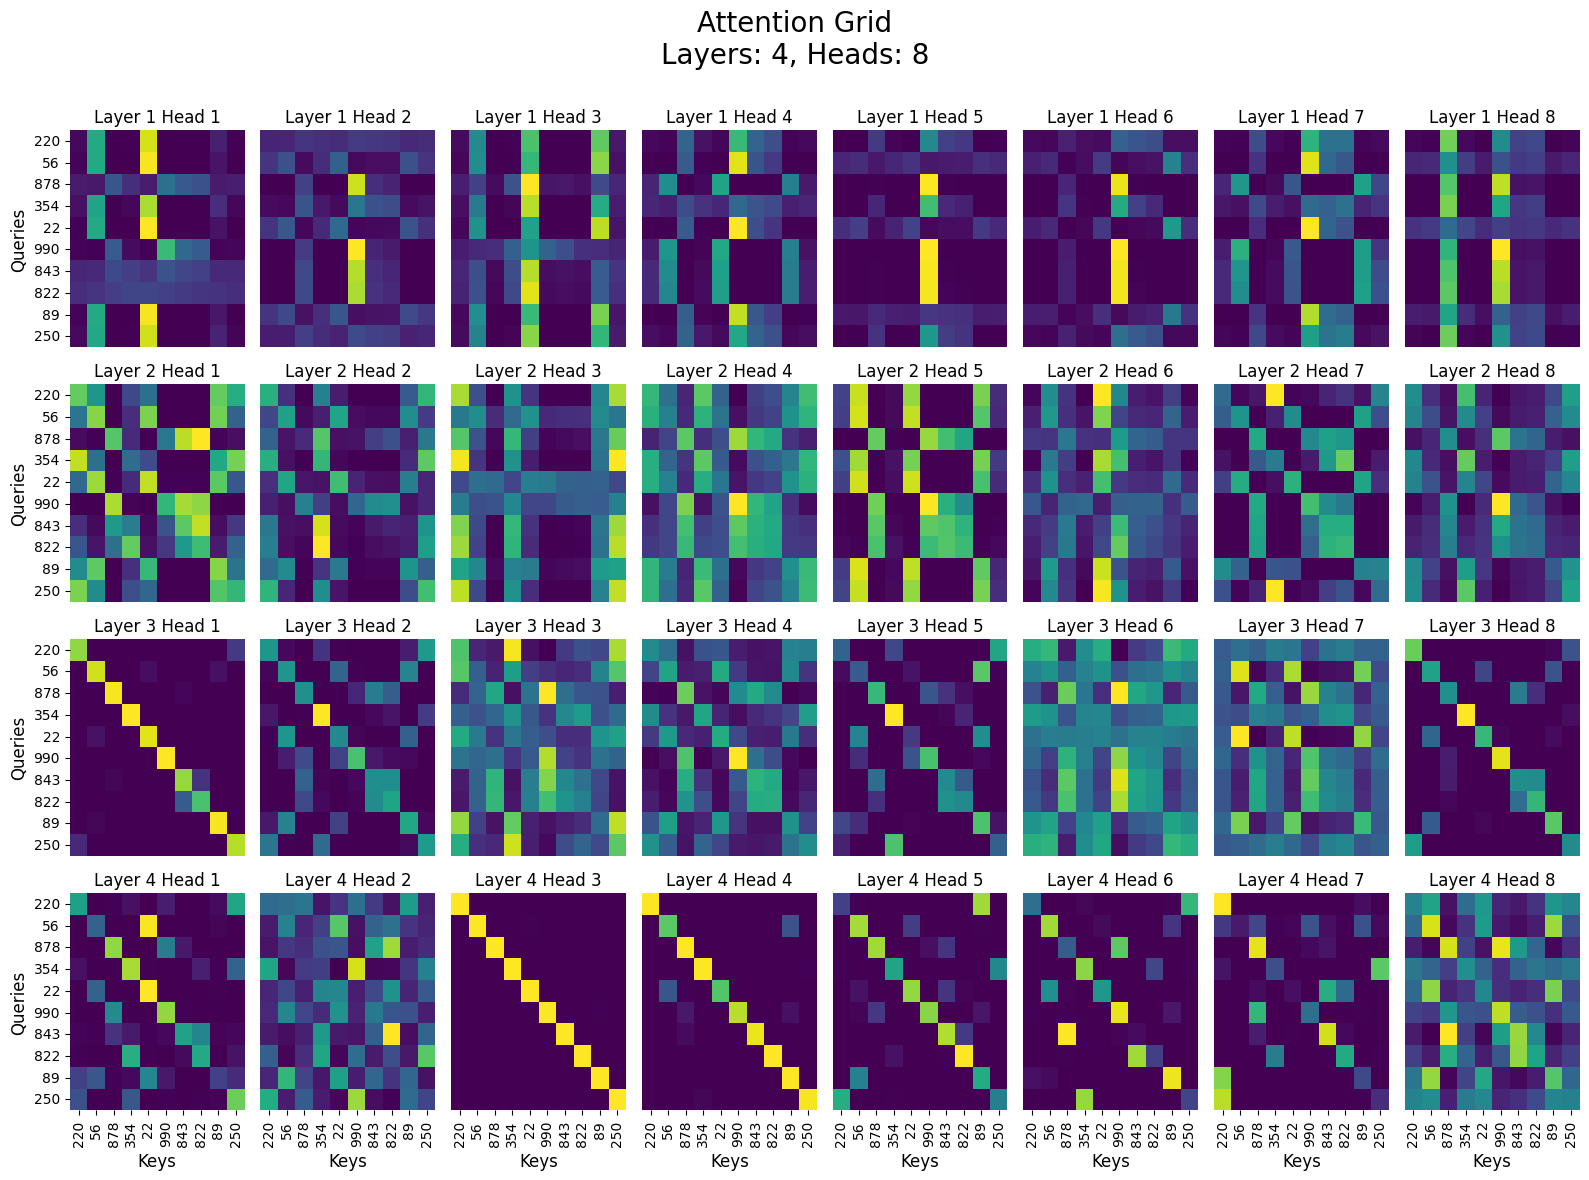

In [ ]:
# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]

# Normalizing the demo sequence and feeding it to the model
demo_sequence = torch.tensor(demo_sequence).float()
norm_sequence = (demo_sequence - demo_sequence.mean())/demo_sequence.std()
norm_sequence = norm_sequence.unsqueeze(0).unsqueeze(-1)

# Getting the attention weights
model_encoder_transformer.eval()
with torch.no_grad():
    norm_sequence = norm_sequence.to(device)
    attention_weights = model_encoder_transformer.attention_weights(norm_sequence)

# Plotting the Attention Weights for the Encoder-Only Transformer
plot_attention_weights(model_encoder_transformer.heads, model_encoder_transformer.layers, attention_weights, demo_sequence)

2. Transformer with Categorical Embeddings

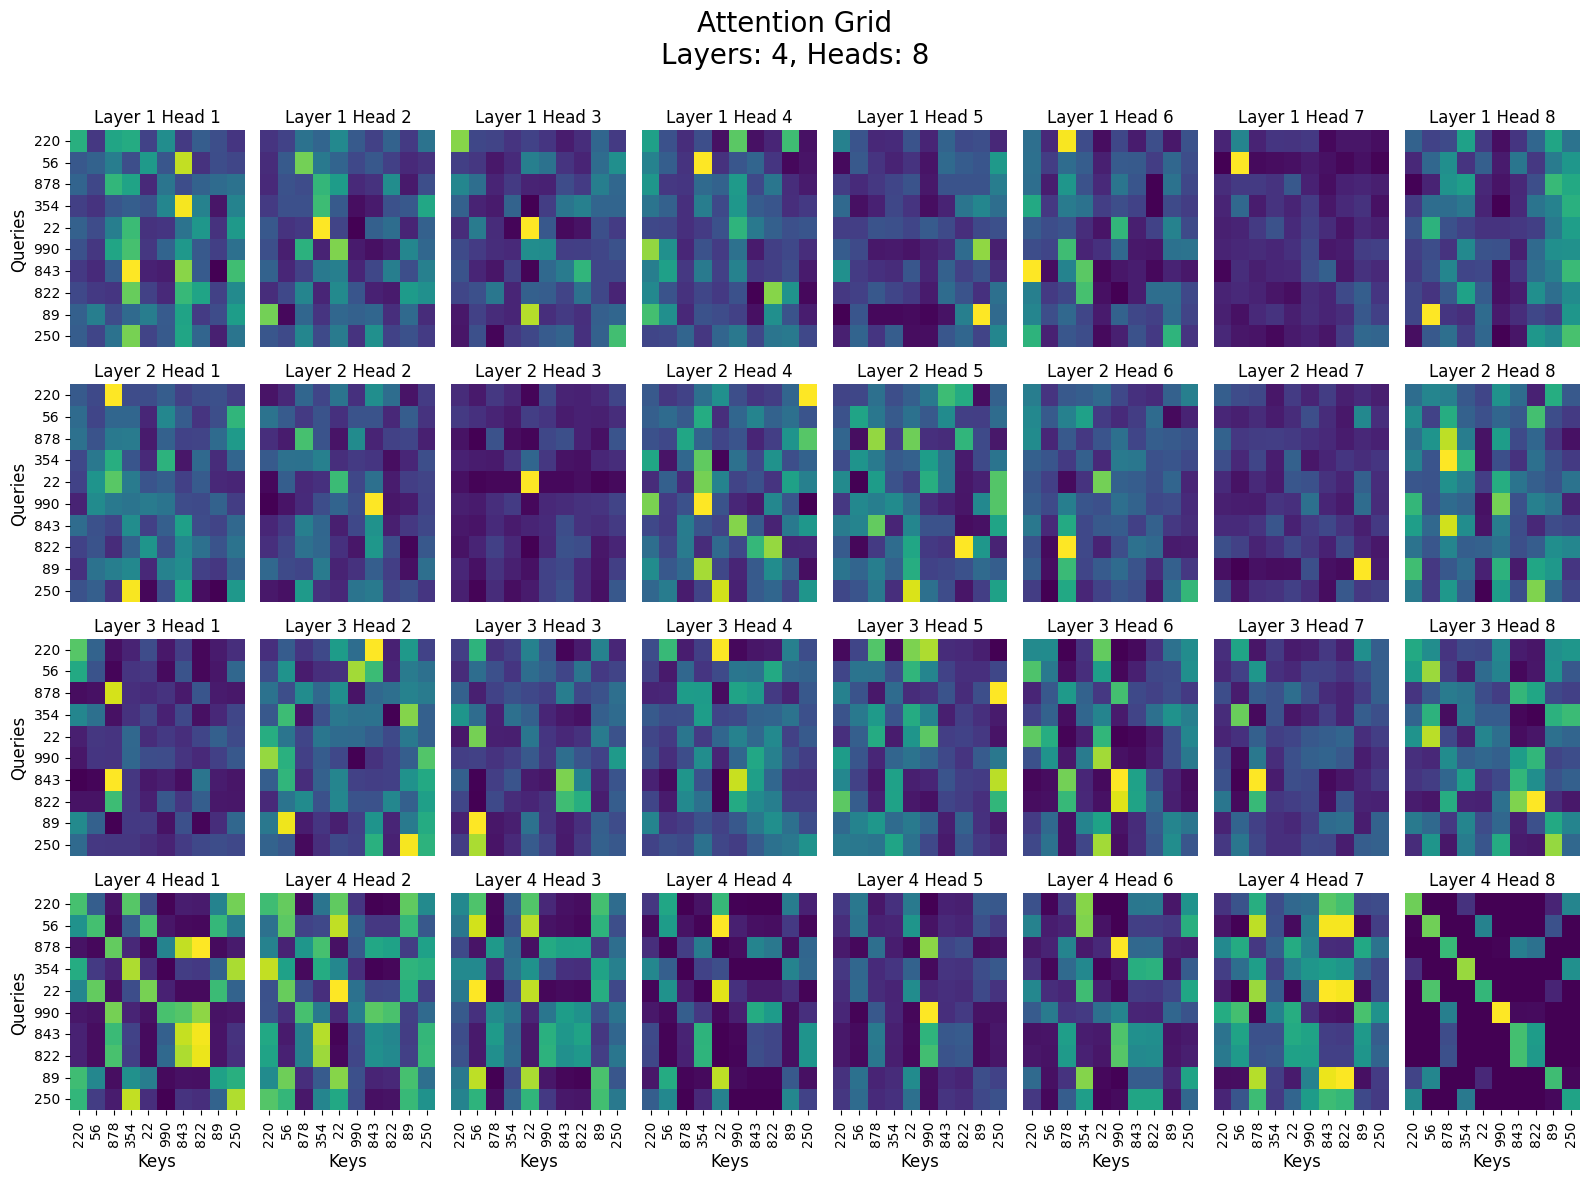

In [ ]:
# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]
demo_sequence = torch.tensor(demo_sequence).long()
input = demo_sequence.unsqueeze(0)

# Getting the attention weights
model_encoder_transformer_cat.eval()
with torch.no_grad():
    input = input.to(device)
    attention_weights = model_encoder_transformer_cat.attention_weights(input)

# Plotting the Attention Weights for the Transformer with Categorical Embeddings
plot_attention_weights(model_encoder_transformer_cat.heads, model_encoder_transformer_cat.layers, attention_weights, demo_sequence)

3. Transformer Without Positional Encodings

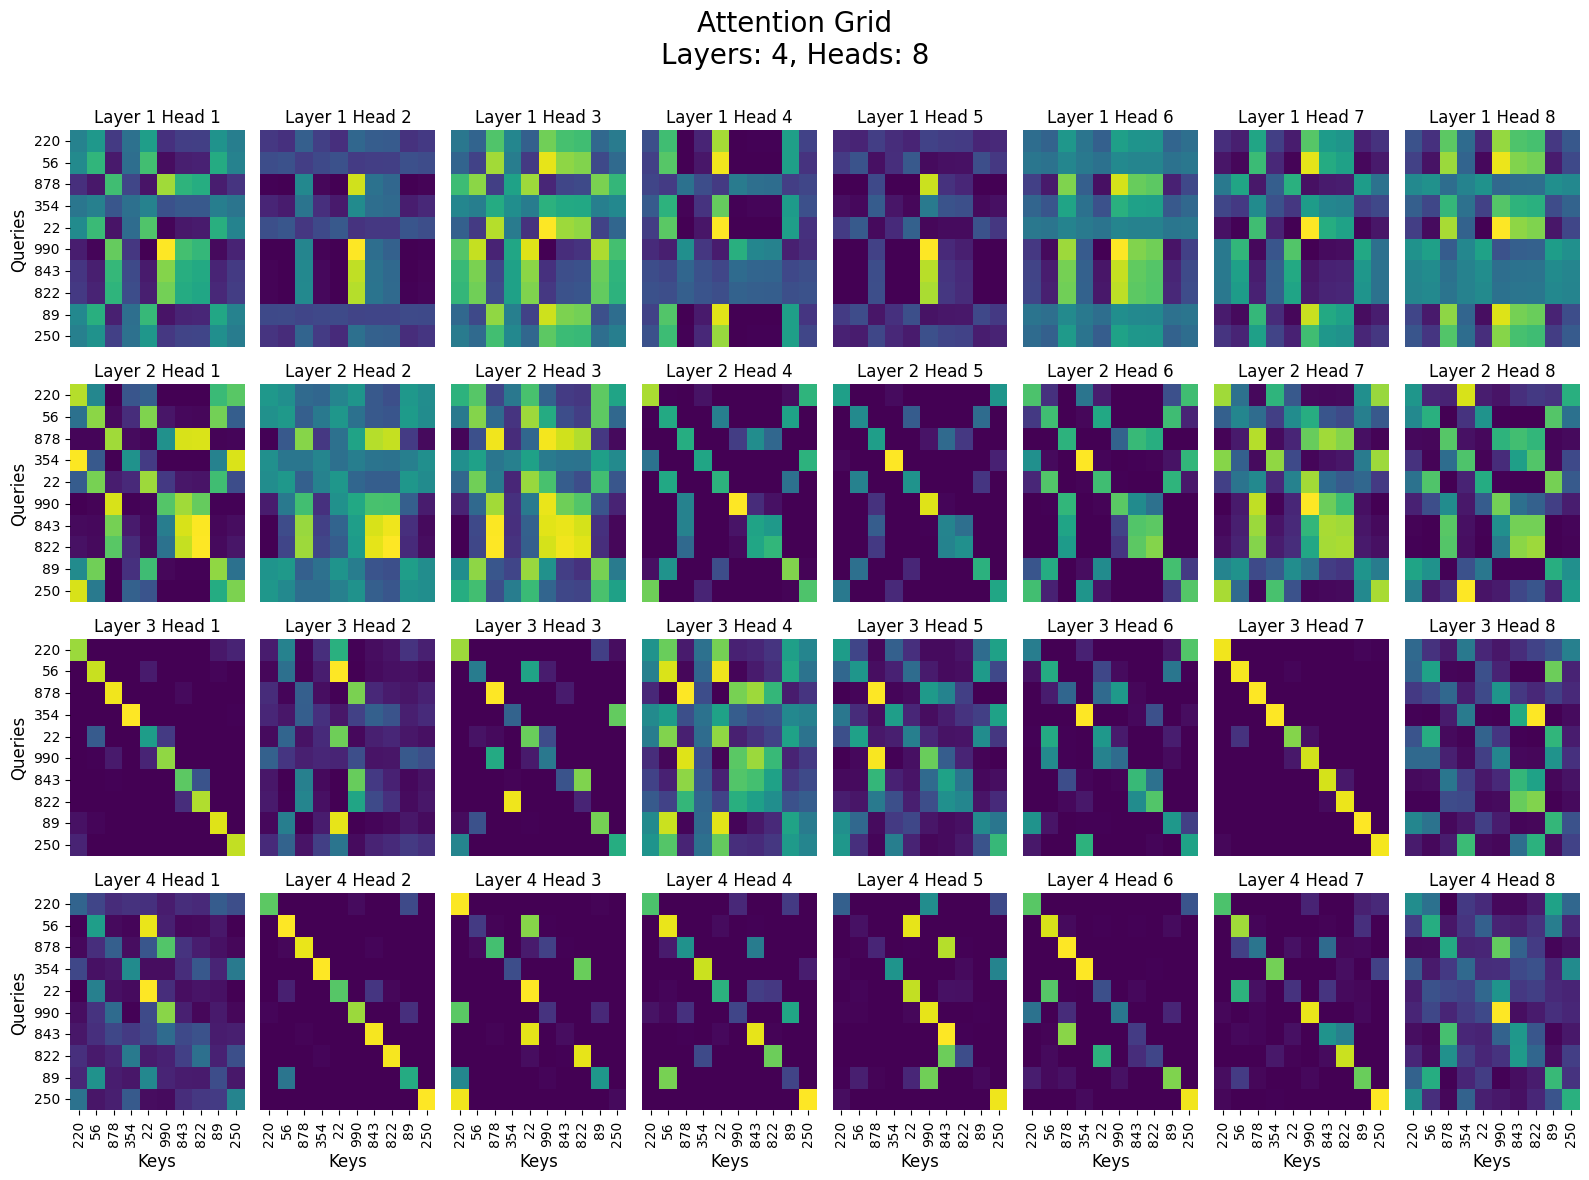

In [ ]:
# User can input their own 10 integer sequence here:
demo_sequence = [220, 56, 878, 354, 22, 990, 843, 822, 89, 250]

# Normalizing the demo sequence and feeding it to the model
demo_sequence = torch.tensor(demo_sequence).float()
norm_sequence = (demo_sequence - demo_sequence.mean())/demo_sequence.std()
norm_sequence = norm_sequence.unsqueeze(0).unsqueeze(-1)

# Getting the attention weights
model_encoder_transformer_no_pos_encodings.eval()
with torch.no_grad():
    norm_sequence = norm_sequence.to(device)
    attention_weights = model_encoder_transformer_no_pos_encodings.attention_weights(norm_sequence)

# Plotting the Attention Weights for the Transformer without Positional Encodings
plot_attention_weights(model_encoder_transformer_no_pos_encodings.heads, model_encoder_transformer_no_pos_encodings.layers, attention_weights, demo_sequence)